## Generating more data with SMOTE (oversampling)

In [51]:
import pandas as pd
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE, ADASYN

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

# to simplify this example, let's filter only some of the variables
df = df[['Age', 'HomeSize', 'EnvironmentalAwareness', 'MonthlyElectricityConsumption', 'MonthlyWaterConsumption', 'Rating']]

<Axes: xlabel='Rating', ylabel='Count'>

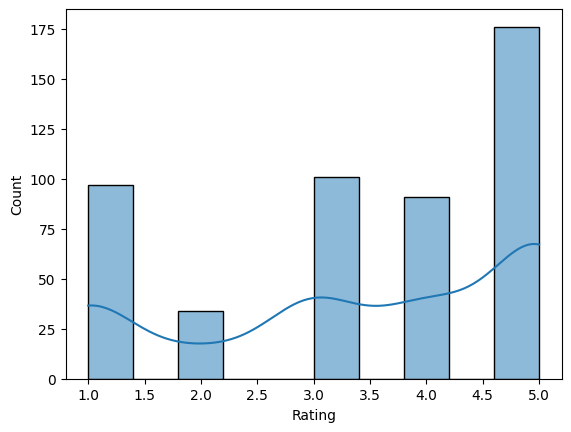

In [52]:
sns.histplot(data=df, x="Rating", kde=True)

## USE SMOTE TO GENERATE MISSING GAPS IN THE DATA

In [53]:
df['Rating'].value_counts().sort_index()

Rating
1     97
2     34
3    101
4     91
5    176
Name: count, dtype: int64

In [54]:
target = "Rating"

X = df.drop(target, axis=1)
y = df[target]

# define sampling strategy
# NOTE! this is oversampling, you can go over the original limit
# because you are generating more data
strategy = {
    1: 200,
    2: 300,
    3: 325,
    4: 300,
    5: 200,
}


# even if you go overboard with the generated data
# the statistics/correlations are still surprisingly close to orginal
# strategy = {
#     1: 1000,
#     2: 1000,
#     3: 1000,
#     4: 1000,
#     5: 1000,
# }

# use SMOTE with default settings (often enough)
# model = SMOTE()
model = SMOTE(sampling_strategy=strategy, random_state=123)

# ADASYN is an alternative to SMOTE, but is often a bit trickier to
# use with custom sampling strategies, you can "auto" though
# model = ADASYN(sampling_strategy="auto", random_state=123)

X_resampled, y_resampled = model.fit_resample(X, y)

# reconstruct the dataframe
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled[target] = y_resampled

<Axes: xlabel='Rating', ylabel='Count'>

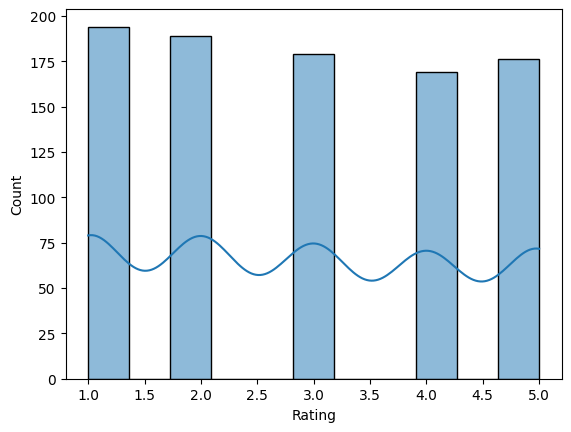

In [55]:
sns.histplot(data=df_resampled, x="Rating", kde=True)

In [56]:
df.describe()

,Age,HomeSize,EnvironmentalAwareness,MonthlyElectricityConsumption,MonthlyWaterConsumption,Rating
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,44.052104,1518.046092,3.062124,291.963928,3139.521042,3.430862
std,14.904828,672.212235,1.342145,120.482275,1224.609306,1.502585
min,18.000000,407.000000,1.000000,55.000000,536.000000,1.000000
25%,31.000000,951.500000,2.000000,185.000000,2000.000000,2.000000
50%,44.000000,1450.000000,3.000000,295.000000,3350.000000,4.000000
75%,58.000000,1995.000000,4.000000,400.000000,4100.000000,5.000000
max,96.000000,2997.000000,5.000000,498.000000,5250.000000,5.000000


In [57]:
df_resampled.describe()

,Age,HomeSize,EnvironmentalAwareness,MonthlyElectricityConsumption,MonthlyWaterConsumption,Rating
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,43.991180,1556.831312,2.683572,313.743109,3236.390298,2.938258
std,14.430924,679.977609,1.291074,110.227635,1207.474579,1.422983
min,18.000000,407.000000,1.000000,55.000000,536.000000,1.000000
25%,32.000000,959.000000,2.000000,226.000000,2076.500000,2.000000
50%,43.000000,1540.000000,3.000000,335.000000,3450.000000,3.000000
75%,56.500000,2054.000000,4.000000,400.000000,4309.500000,4.000000
max,96.000000,2997.000000,5.000000,498.000000,5250.000000,5.000000


In [58]:
df.corr()[target].sort_values(ascending=False)

Rating                           1.000000
EnvironmentalAwareness           0.589104
HomeSize                         0.041610
Age                             -0.062691
MonthlyWaterConsumption         -0.557345
MonthlyElectricityConsumption   -0.571783
Name: Rating, dtype: float64

In [59]:
df_resampled.corr()[target].sort_values(ascending=False)

Rating                           1.000000
EnvironmentalAwareness           0.606363
HomeSize                         0.002857
Age                             -0.033244
MonthlyWaterConsumption         -0.417595
MonthlyElectricityConsumption   -0.531064
Name: Rating, dtype: float64

### even though we also tried to have 90% of synthetic data, the result were still surprisingly good